<a href="https://colab.research.google.com/github/sofyadmitrieva/python-ML-basics/blob/main/log_reg_hw_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

### **2. Анализ данных**

In [9]:
# Ваш код здесь
# Подсказка: используйте value_counts()

# Сколько всего текстов
total_texts = len(data)
print("Всего текстов:", total_texts)

# Количество текстов в каждой категории
counts = data['category'].value_counts()
print("\nКоличество текстов по категориям:")
print("Хоккей:", counts[0])
print("Космос:", counts[1])

# Определяем, какая категория больше
if counts[0] > counts[1]:
    print('\nБольше всего текстов в категории "хоккей"')
elif counts[1] > counts[0]:
    print('\nБольше всего текстов в категории "космос"')
else:
    print("\nКоличество текстов в категориях одинаковое")

Всего текстов: 1986

Количество текстов по категориям:
Хоккей: 999
Космос: 987

Больше всего текстов в категории "хоккей"


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [10]:
import re

def clean_text(text):
    # Ваш код здесь
    # 1. Привести текст к нижнему регистру (.lower())
    # 2. Удалить всё, кроме букв и пробелов (re.sub)
    # 3. Убрать лишние пробелы
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
    pass

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("После очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.
После очистки: from mccallmksoldsegticom fred j mccall subject re vandalizing the sky articleid mksolapr organizati


### **4. Создание признаков (векторизация)**

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Ваш код здесь
# 1. Создайте CountVectorizer (остановитесь на английском)
# 2. Преобразуйте тексты в числа (fit_transform)
# 3. Выведите сколько слов получилось

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(data['clean_text'])
y = data['category']
print("Количество уникальных слов:", len(vectorizer.get_feature_names_out()))

Количество уникальных слов: 28383


In [18]:
data['clean_text'].head()

,clean_text
0,from mccallmksoldsegticom fred j mccall subjec...
1,from epritchaspsychuiucedu evan pritchard subj...
2,from baalkekelvinjplnasagov ron baalke subject...
3,from mseccbellcorecom michael evenchickf subje...
4,from apanjabiguvaxaccgeorgetownedu subject re ...


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [20]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = X # что сюда подставить? (признаки)
y = data['category']  # что сюда подставить? (целевая переменная)

# Ваш код здесь
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1588, 28383)
Размер тестовой выборки: (398, 28383)


### **6. Обучение модели**

In [21]:
from sklearn.linear_model import LogisticRegression

# Ваш код здесь
# 1. Создайте модель логистической регрессии
# 2. Обучите её на обучающих данных
# 3. Сделайте предсказания для тестовых данных

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### **7. Оценка модели**

In [22]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
# 2. Выведите результат в процентах

accuracy = accuracy_score(y_test, y_pred)
print("Точность модели:", accuracy * 100, "%")

Точность модели: 99.2462311557789 %


**Вопрос:** Какая точность у вашей модели? Что это значит?

**Ответ:** Точность модели составляет примерно 99,25%. Это означает, что она умеет хорошо определять тексты про хоккей и космос.

### **8. Анализ ошибок**

Матрица ошибок:
[[201   1]
 [  2 194]]


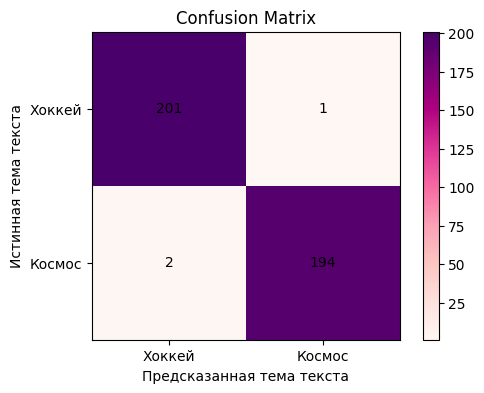

In [27]:
from sklearn.metrics import confusion_matrix

# Ваш код здесь
# 1. Создайте матрицу ошибок
# 2. Выведите её

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

# БОНУС: визуализируйте матрицу ошибок
plt.figure(figsize=(6, 4))
# Ваш код для визуализации здесь
plt.imshow(cm, cmap ='RdPu')
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Предсказанная тема текста")
plt.ylabel("Истинная тема текста")

plt.xticks([0,1], ["Хоккей", "Космос"])
plt.yticks([0,1], ["Хоккей", "Космос"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.show()

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?

Модель ошибочно классифицировала 2 текста про космос как хоккей.